<a href="https://colab.research.google.com/github/selvapreethi2006-hue/Data-Analytics-On-Some-Online-Ecommerce/blob/main/E_commerce_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Import CSV File
from google.colab import files
uploaded = files.upload()Import CSV


Saving ecommerce_orders.csv to ecommerce_orders.csv


In [ ]:
#Load the data
df = pd.read_csv('ecommerce_orders.csv')
print("Shape:", df.shape)
print(df.head())
print(df.dtypes)

Shape: (5015, 15)
    order_id customer_id customer_country           order_date  category  \
0  ORD000001   CUST00883            India  2024-09-07 01:00:00  Clothing   
1  ORD000002   CUST00846              USA  2024-10-29 05:00:00  Clothing   
2  ORD000003   CUST00760          Germany  2025-05-10 07:00:00      Toys   
3  ORD000004   CUST01019           Canada  2024-10-29 11:00:00    Sports   
4  ORD000005   CUST01438               UK  2024-11-16 16:00:00  Clothing   

         product  quantity  unit_price  discount_pct  discount_amount  \
0         Hoodie         2       53.96           0.0              0.0   
1          Jeans         1       33.27           0.0              0.0   
2  Action Figure         4       38.99           5.0              7.8   
3      Dumbbells         1       14.20           0.0              0.0   
4         Hoodie         1       52.70           0.0              0.0   

   gross_amount  net_amount         channel payment_method order_status  
0        107

In [ ]:
#Inspect for issues
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique countries:", df['customer_country'].unique())
print("\nUnique order statuses:", df['order_status'].unique())

Missing values:
 order_id             0
customer_id          0
customer_country     0
order_date           0
category             0
product              0
quantity             0
unit_price           0
discount_pct        40
discount_amount      0
gross_amount         0
net_amount           0
channel              0
payment_method       0
order_status         0
dtype: int64

Duplicate rows: 15

Unique countries: ['India' 'USA' 'Germany' 'Canada' 'UK' 'Australia' 'U.S.A'
 'United Kingdom']

Unique order statuses: ['Completed' 'Returned' 'Cancelled']


In [ ]:
#Clean the data
df = df.drop_duplicates()

df['customer_country'] = df['customer_country'].replace({
    'U.S.A': 'USA',
    'United Kingdom': 'UK'
})

df['order_date'] = pd.to_datetime(df['order_date'])

mask = df['discount_pct'].isna()
df.loc[mask, 'discount_pct'] = (df.loc[mask, 'discount_amount'] / df.loc[mask, 'gross_amount'] * 100).round(1)

assert (df['quantity'] > 0).all()
assert (df['net_amount'] >= 0).all()

print("Cleaned shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

Cleaned shape: (5000, 15)
Remaining missing values: 0


In [ ]:
#Feature engineering
df['order_month'] = df['order_date'].dt.to_period('M').astype(str)
df['order_weekday'] = df['order_date'].dt.day_name()
df['is_returned_or_cancelled'] = df['order_status'].isin(['Returned', 'Cancelled'])

sales_df = df[df['order_status'] == 'Completed'].copy()

In [ ]:
#Core KPIs
total_revenue = sales_df['net_amount'].sum()
total_orders = sales_df['order_id'].nunique()
aov = total_revenue / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ${aov:,.2f}")

Total Revenue: $305,285.48
Total Orders: 4,455
Average Order Value: $68.53


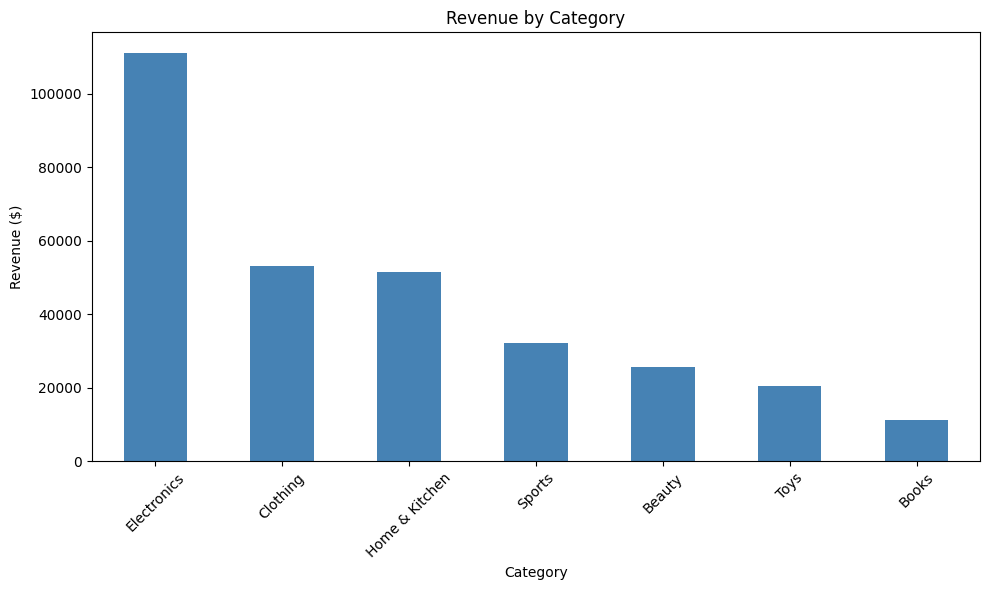

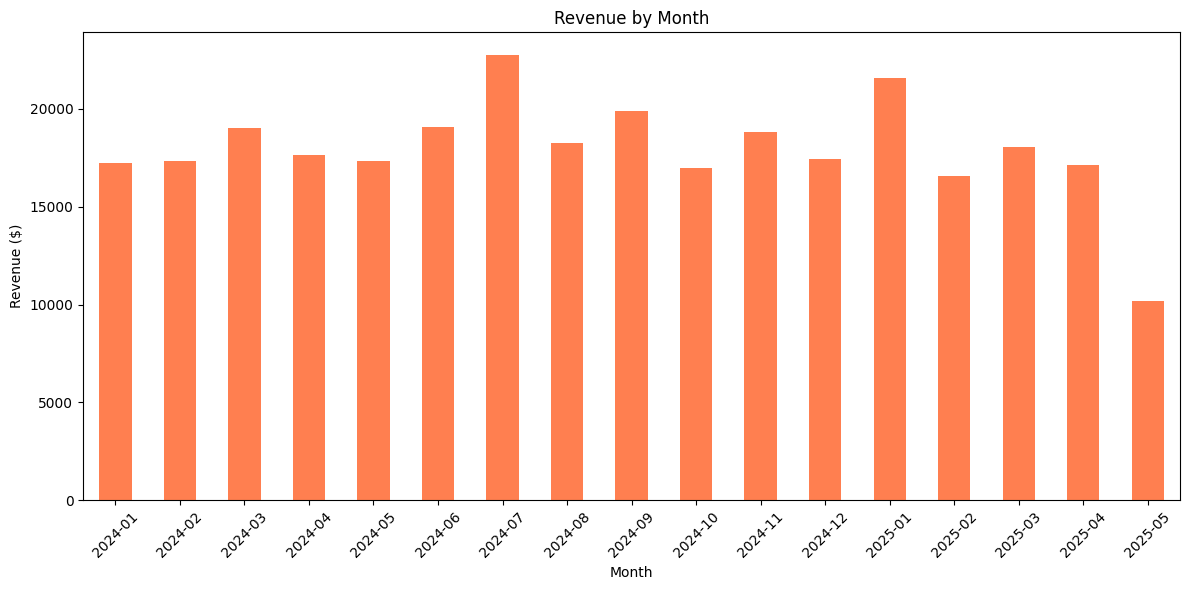

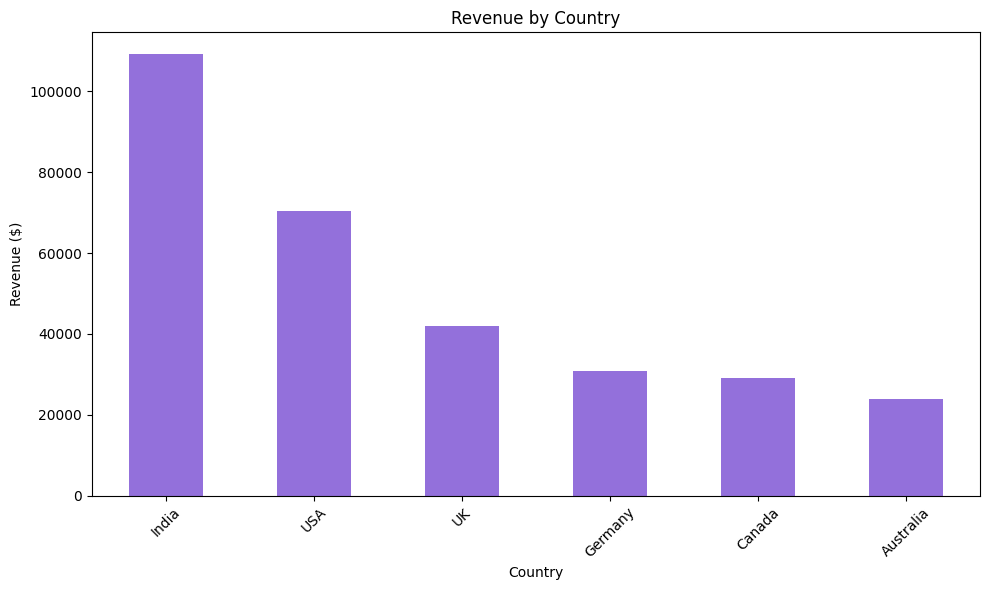

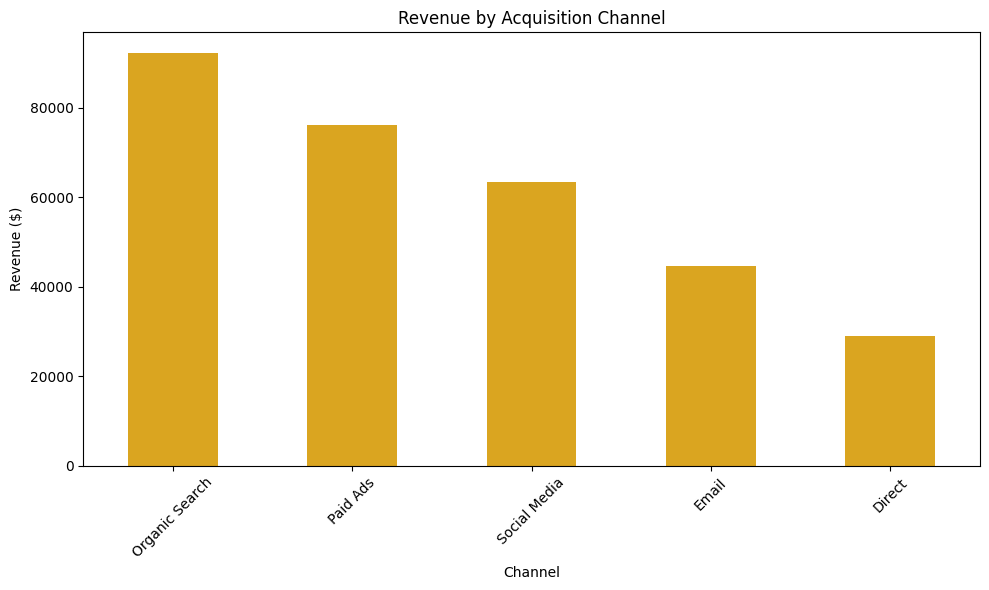

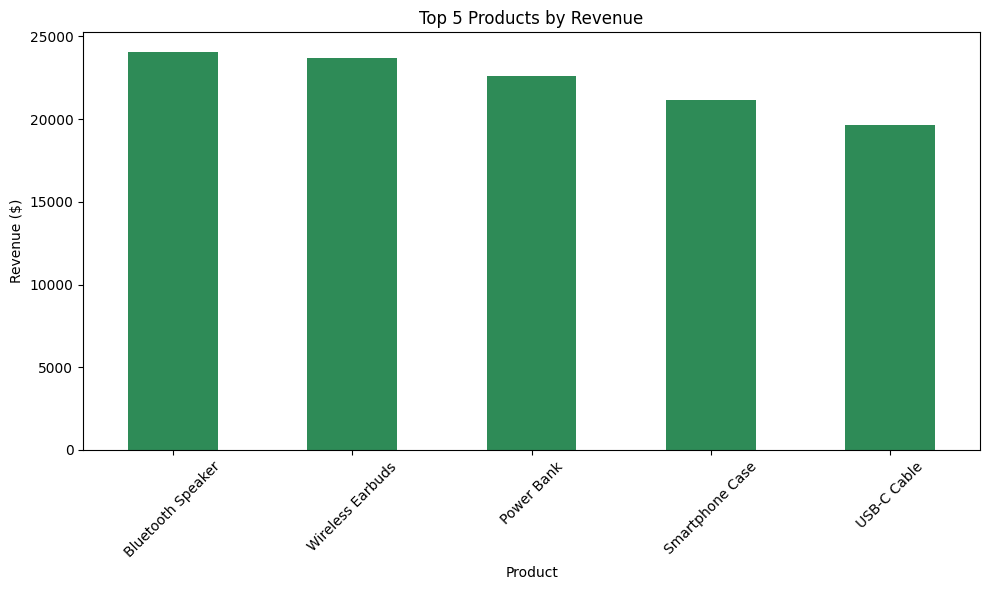

In [ ]:
#EDA
# Chart 1: Revenue by Category
plt.figure(figsize=(10, 6))
rev_by_cat.plot(kind='bar', color='steelblue')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_category_chart.png')
plt.show()

# Chart 2: Revenue by Month
plt.figure(figsize=(12, 6))
rev_by_month.plot(kind='bar', color='coral')
plt.title('Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_month_chart.png')
plt.show()

# Chart 3: Revenue by Country
plt.figure(figsize=(10, 6))
rev_by_country.plot(kind='bar', color='mediumpurple')
plt.title('Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_country_chart.png')
plt.show()

# Chart 4: Revenue by Channel
plt.figure(figsize=(10, 6))
rev_by_channel.plot(kind='bar', color='goldenrod')
plt.title('Revenue by Acquisition Channel')
plt.xlabel('Channel')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_channel_chart.png')
plt.show()

# Chart 5: Top 5 Products by Revenue
plt.figure(figsize=(10, 6))
top_products.plot(kind='bar', color='seagreen')
plt.title('Top 5 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_products_chart.png')
plt.show()

In [ ]:
#Return/cancellation rate
return_rate = df['is_returned_or_cancelled'].mean() * 100
print(f"{return_rate:.2f}% of all orders are returned or cancelled")

10.90% of all orders are returned or cancelled


In [ ]:
#RFM analysis
snapshot_date = sales_df['order_date'].max() + pd.Timedelta(days=1)

rfm = sales_df.groupby('customer_id').agg(
    recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('net_amount', 'sum')
).reset_index()

rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4]).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def segment(row):
    if row['RFM_score'] >= 10:
        return 'Champions'
    elif row['RFM_score'] >= 8:
        return 'Loyal Customers'
    elif row['RFM_score'] >= 6:
        return 'Potential Loyalists'
    elif row['RFM_score'] >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(segment, axis=1)
print(rfm['segment'].value_counts())

segment
Champions              396
Potential Loyalists    340
Loyal Customers        319
At Risk                239
Lost                   126
Name: count, dtype: int64
